/Users/ricardorivero/anaconda3/lib/python3.11/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
/var/folders/8v/6y3r5h_x0dv5t5875drggrtc0000gn/T/ipykernel_77995/631989695.py:94: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  e_aln_encoded = e_aln_df.iloc[:, 1:].replace(amino_acid_encoding)


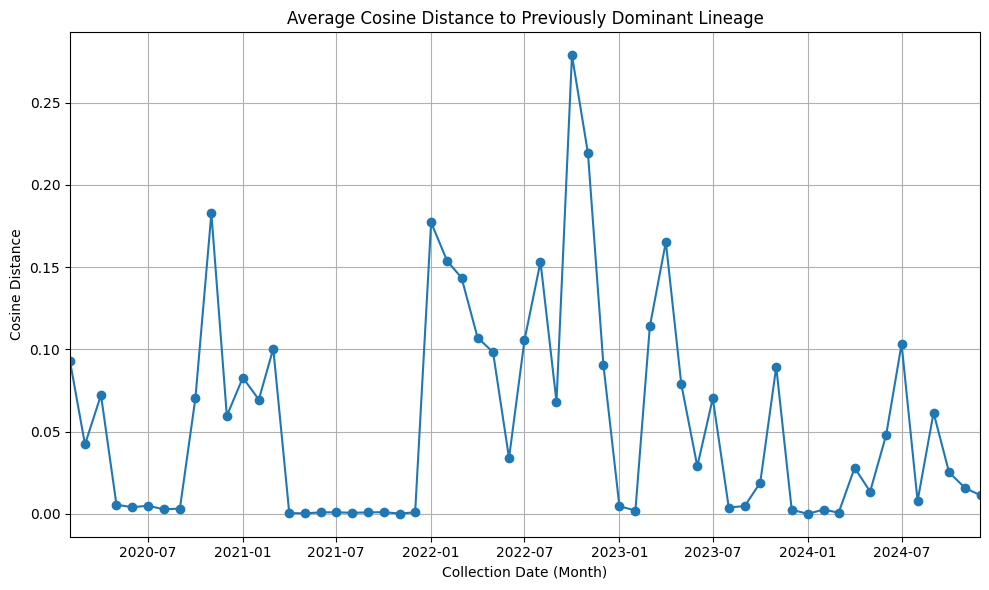

,month,distance_to_dominant
0,2020-02-01,0.092619
1,2020-03-01,0.042140
2,2020-04-01,0.072174
3,2020-05-01,0.005551
4,2020-06-01,0.003951
...,...,...
91,2027-09-01,0.054386
92,2027-10-01,0.162623
93,2027-11-01,0.001191
94,2027-12-01,0.237118


In [10]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import AlignIO, SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from scipy.spatial.distance import cosine
from sklearn.decomposition import PCA  # if you want to check reduced variance later

# =============================================================================
# 0. Load and Merge Lineage (clade) Data from TSV Files
# =============================================================================
# Load all TSV files that contain lineage assignations.
datasets = []
for file in glob.glob('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/*.tsv'):
    datasets.append(pd.read_table(file))

# Concatenate all datasets
df = pd.concat(datasets, ignore_index=True)

# Filter out observations with alignment errors
substring = "When calculating seed matches: Unable to align"
filtered_datasets = df[~df['errors'].str.startswith(substring, na=False)]

# Keep only the desired columns and process sequence names
filtered_datasets = filtered_datasets[['seqName', 'clade', 'aaSubstitutions', 'aaDeletions', 'aaInsertions']]
filtered_datasets['strain'] = filtered_datasets['seqName'].str.split('|').str[0]

# =============================================================================
# 1. Load GISAID Metadata and Merge with Clade Information
# =============================================================================
gisaid_metadata = pd.read_table('/Users/ricardorivero/Documents/DENV/dimensionality_reduction/colombian_seqs_pca.tsv')
# Merge to assign lineages; here 'Virus name' is merged with the 'strain' from filtered_datasets
gisaid_metadata = gisaid_metadata.merge(filtered_datasets, left_on='Virus name', right_on='strain', how='left')

# Rename for consistency
gisaid_metadata.rename(columns={'Virus name': 'sequence_name'}, inplace=True)

# For this example, if a proper collection date is missing, simulate one:
if 'collection_date' not in gisaid_metadata.columns:
    gisaid_metadata['collection_date'] = pd.date_range(start='2020-01-01', periods=len(gisaid_metadata), freq='W')

# =============================================================================
# 2. Load Alignment and Process the E Gene Region
# =============================================================================
# Load the aligned nucleotide sequences (subset to the region covering the E gene)
aligned_filepath = '/Users/ricardorivero/Documents/DENV/dimensionality_reduction/colombian_seqs_pca.aligned.fasta'
align = AlignIO.read(aligned_filepath, "fasta")
start_pos = 934   # (0-indexed; corresponds to 935 in 1-indexed)
end_pos = 2418    # slicing is exclusive at the end
subset_align = align[:, start_pos:end_pos]

# =============================================================================
# 3. Translate Nucleotide Sequences to Protein and Encode Them
# =============================================================================
protein_records = []
for record in subset_align:
    dna_seq = str(record.seq)
    protein_seq = Seq(dna_seq).translate(to_stop=False)
    # Use the first part of the ID (adjust if necessary)
    protein_record = SeqRecord(protein_seq, id=record.id.split('|')[0], description="")
    protein_records.append(protein_record)

# Save the translated protein alignment (optional)
translated_aln_path = '/Users/ricardorivero/Documents/DENV/dimensionality_reduction/subsetted_E_alignment_protein.fasta'
with open(translated_aln_path, 'w') as output_handle:
    SeqIO.write(protein_records, output_handle, "fasta")

# Reload the protein alignment
eprot_align = AlignIO.read(translated_aln_path, "fasta")

# Build a DataFrame: each row is a sequence; columns are positions.
data = {record.id: list(str(record.seq)) for record in eprot_align}
e_aln_df = pd.DataFrame.from_dict(data, orient='index')
e_aln_df.reset_index(inplace=True)
e_aln_df.rename(columns={'index': 'sequence_name'}, inplace=True)
# Rename columns so positions are 1-indexed:
e_aln_df.columns = ['sequence_name'] + [f'pos_{i+1}' for i in range(e_aln_df.shape[1] - 1)]

# Define an amino acid encoding dictionary
amino_acid_encoding = {
    'A': 0, 'C': 1, 'D': 2, 'E': 3, 'F': 4, 'G': 5,
    'H': 6, 'I': 7, 'K': 8, 'L': 9, 'M': 10, 'N': 11,
    'P': 12, 'Q': 13, 'R': 14, 'S': 15, 'T': 16,
    'V': 17, 'W': 18, 'Y': 19, 'X': -1  # Unknown/missing
}

# Replace any non-standard characters with 'X'
e_aln_df.iloc[:, 1:] = e_aln_df.iloc[:, 1:].replace(to_replace=r'[^ACDEFGHIKLMNPQRSTVWYX]', value='X', regex=True)

# Convert amino acids to numeric encoding
e_aln_encoded = e_aln_df.iloc[:, 1:].replace(amino_acid_encoding)

# Convert to numpy array (each row is a numeric vector for a sequence)
seq_matrix = e_aln_encoded.values.astype(float)

# =============================================================================
# 4. Merge Alignment Data with Metadata and Prepare the Timeseries
# =============================================================================
# Ensure sequence names are trimmed and consistent
e_aln_df['sequence_name'] = e_aln_df['sequence_name'].str.strip()
gisaid_metadata['sequence_name'] = gisaid_metadata['sequence_name'].str.strip()

# Merge metadata with the alignment (keep only the sequence names from the alignment)
merged_df = pd.merge(e_aln_df[['sequence_name']], gisaid_metadata, on='sequence_name', how='left')

# Add the encoded sequence as a new column (each row gets its numeric vector)
merged_df['encoded_vector'] = list(seq_matrix)

# Convert collection_date to datetime and sort
merged_df['collection_date'] = pd.to_datetime(merged_df['collection_date'])
merged_df.sort_values(by='collection_date', inplace=True)

# =============================================================================
# 5. Define Helper Functions for Dominant Lineage and Cosine Distance
# =============================================================================
def find_majority_lineage(df_window):
    """
    Given a DataFrame with a 'clade' column for sequences in a time window,
    return the lineage (clade) that appears most frequently.
    """
    counts = df_window['clade'].value_counts()
    return counts.idxmax() if not counts.empty else None

def average_vector(vectors):
    """
    Compute the element-wise average of a list of numeric vectors.
    """
    if len(vectors) == 0:
        return None
    return np.mean(np.stack(vectors), axis=0)

def compute_cosine_distance(vec1, vec2):
    """
    Compute the cosine distance between two vectors.
    """
    return cosine(vec1, vec2)

# =============================================================================
# 6. Group Sequences by Time Window and Compute 1D Distance
# =============================================================================
# For demonstration, group sequences by month.
merged_df['month'] = merged_df['collection_date'].dt.to_period('M')

results = []
time_windows = sorted(merged_df['month'].unique())

# Loop through time windows; skip the first window (no previous data available)
for i in range(1, len(time_windows)):
    current_window = time_windows[i]
    previous_window = time_windows[i-1]
    
    # Get sequences from the previous window
    prev_df = merged_df[merged_df['month'] == previous_window]
    dominant_lineage = find_majority_lineage(prev_df)
    
    if dominant_lineage is None:
        continue
    
    # Get vectors for the dominant lineage in the previous window
    ref_vectors = prev_df[prev_df['clade'] == dominant_lineage]['encoded_vector'].tolist()
    ref_vectors = [np.array(vec) for vec in ref_vectors if vec is not None]
    
    if len(ref_vectors) == 0:
        continue
    
    # Compute the average vector as the reference
    ref_vector = average_vector(ref_vectors)
    
    # For each sequence in the current window, compute cosine distance to the reference vector
    current_df = merged_df[merged_df['month'] == current_window]
    for idx, row in current_df.iterrows():
        seq_vector = np.array(row['encoded_vector'])
        dist = compute_cosine_distance(seq_vector, ref_vector)
        results.append({
            'sequence_name': row['sequence_name'],
            'collection_date': row['collection_date'],
            'month': current_window,
            'clade': row['clade'],
            'distance_to_dominant': dist,
            'dominant_lineage': dominant_lineage,
        })

results_df = pd.DataFrame(results)

# =============================================================================
# 7. Plot the Timeseries of Cosine Distances
# =============================================================================
if not results_df.empty:
    monthly_avg = results_df.groupby('month')['distance_to_dominant'].mean().reset_index()
    monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

    plt.figure(figsize=(10, 6))
    plt.plot(monthly_avg['month'], monthly_avg['distance_to_dominant'], marker='o')
    plt.title('Average Cosine Distance to Previously Dominant Lineage')
    plt.xlabel('Collection Date (Month)')
    plt.ylabel('Cosine Distance')
    plt.grid(True)
    plt.tight_layout()
    plt.xlim(monthly_avg['month'].min(), pd.Timestamp('2024-11-30'))
    plt.show()
else:
    print("No results to plot. Verify that your metadata and grouping are correct.")

# =============================================================================
# End of Workflow
# =============================================================================

"""
Notes:
- This script now first loads the TSV files containing clade assignments and merges them with your GISAID metadata.
- The alignment is processed (translated, subsetted, and numerically encoded) similarly to your previous notebook.
- Sequences are grouped by month, and for each window (after the first) the dominant lineage from the previous window is used to compute the cosine distance.
- Adjust time grouping, file paths, or encoding details as needed for your specific dataset.
"""

monthly_avg

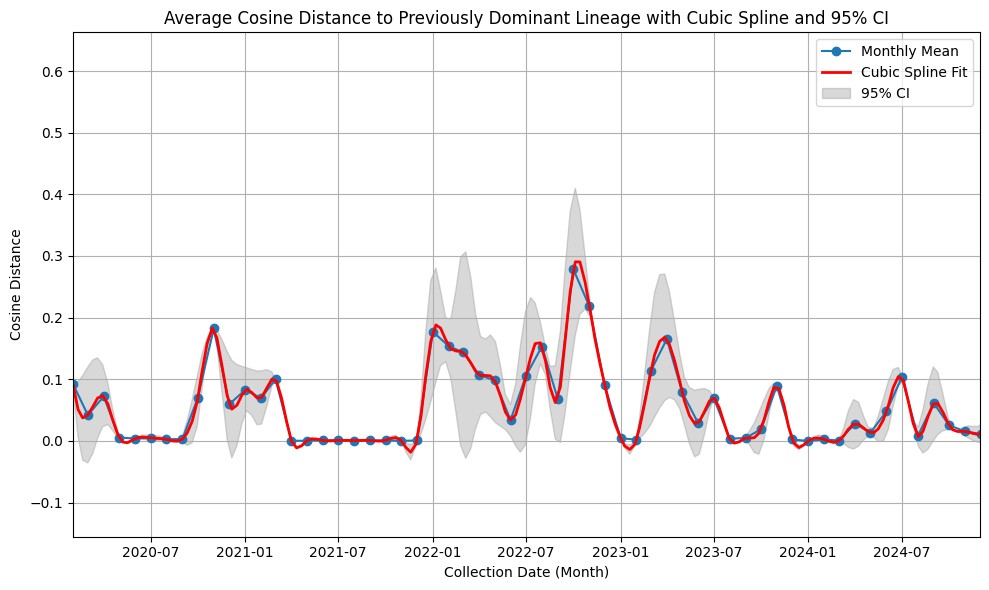

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

# -------------------------------
# 1. Compute Monthly Statistics
# -------------------------------
# Assuming results_df has a 'month' column (of Period type) and 'distance_to_dominant'
monthly_stats = results_df.groupby('month').agg(
    mean_distance=('distance_to_dominant', 'mean'),
    std_distance=('distance_to_dominant', 'std'),
    count=('distance_to_dominant', 'count')
).reset_index()

# Compute the standard error and the 95% confidence interval bounds.
monthly_stats['se'] = monthly_stats['std_distance'] / np.sqrt(monthly_stats['count'])
monthly_stats['lower'] = monthly_stats['mean_distance'] - 1.96 * monthly_stats['se']
monthly_stats['upper'] = monthly_stats['mean_distance'] + 1.96 * monthly_stats['se']

# Convert the 'month' column (Period) to Timestamp for plotting
monthly_stats['month'] = monthly_stats['month'].dt.to_timestamp()

# ------------------------------------------
# 2. Fit Cubic Splines to the Mean and CIs
# ------------------------------------------
# Convert the datetime values to numeric (ordinal) for interpolation
x = monthly_stats['month'].map(pd.Timestamp.toordinal).values
y_mean = monthly_stats['mean_distance'].values
y_lower = monthly_stats['lower'].values
y_upper = monthly_stats['upper'].values

# Generate a fine grid for a smooth curve
xnew = np.linspace(x.min(), x.max(), 300)

# Fit cubic splines (degree=3) to the mean and the CI bounds
spline_mean = make_interp_spline(x, y_mean, k=3)
ynew_mean = spline_mean(xnew)

spline_lower = make_interp_spline(x, y_lower, k=3)
ynew_lower = spline_lower(xnew)

spline_upper = make_interp_spline(x, y_upper, k=3)
ynew_upper = spline_upper(xnew)

# Convert the numeric x-values back to datetime for plotting
xnew_dates = [pd.Timestamp.fromordinal(int(round(val))) for val in xnew]

# -------------------------------
# 3. Plot the Data and Confidence Intervals
# -------------------------------
plt.figure(figsize=(10, 6))
# Plot the original monthly means (line+scatter)
plt.plot(monthly_stats['month'], monthly_stats['mean_distance'], 'o-', label='Monthly Mean')
# Plot the spline fit to the mean
plt.plot(xnew_dates, ynew_mean, label='Cubic Spline Fit', color='red', linewidth=2)
# Fill between the lower and upper spline curves for the 95% CI
plt.fill_between(xnew_dates, ynew_lower, ynew_upper, color='gray', alpha=0.3, label='95% CI')

# Limit the x-axis up to November 2024 (you can adjust the lower limit as needed)
plt.xlim(monthly_stats['month'].min(), pd.Timestamp('2024-11-30'))

plt.xlabel('Collection Date (Month)')
plt.ylabel('Cosine Distance')
plt.title('Average Cosine Distance to Previously Dominant Lineage with Cubic Spline and 95% CI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()